# ML Student Performance Prediction and Model Evaluation — Day 18 & 19

## Assignment Objective

This notebook follows a complete machine-learning workflow using the **exact Student Performance dataset supplied for the assignment**.

The analysis covers:

1. Exploratory Data Analysis (EDA)
2. Data quality assessment
3. Relationships and correlations with `exam_score`
4. Feature selection and preprocessing
5. Linear Regression for predicting `exam_score`
6. Pass/Fail classification using a **50-mark threshold**
7. Confusion matrix, accuracy, precision, recall, and F1-score
8. Training-versus-testing performance comparison
9. Overfitting/underfitting assessment
10. Five meaningful, data-supported student-performance insights

**Dataset integrity:** No rows, columns, or values are fabricated. The notebook uses the supplied CSV as provided.

## 1. Import Libraries

The libraries below support data loading and inspection, statistical exploration, visualization, preprocessing, regression, classification, and model evaluation.

The workflow uses **Pandas, NumPy, Matplotlib, Seaborn, and scikit-learn**, which are appropriate for the requested EDA and machine-learning tasks.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Exact Student Performance Dataset

The notebook expects the supplied file:

`Day18_19_student_habits_performance.csv`

In Google Colab, upload the CSV to the notebook session if it is not already present. The code does not create or fabricate a replacement dataset.

In [2]:
DATA_FILE = "Day18_19_student_habits_performance.csv"

if not os.path.exists(DATA_FILE):
    try:
        from google.colab import files
        uploaded = files.upload()
        csv_candidates = [name for name in uploaded if name.lower().endswith(".csv")]
        if not csv_candidates:
            raise FileNotFoundError("No CSV file was uploaded.")
        DATA_FILE = csv_candidates[0]
    except ImportError:
        raise FileNotFoundError(
            f"'{DATA_FILE}' was not found. Place the supplied CSV in the notebook folder."
        )

df = pd.read_csv(DATA_FILE)

print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Dataset loaded successfully: 1,000 rows × 16 columns


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 3. Initial Dataset Inspection — First Five Records

`head()` provides an immediate view of the observations, column names, and the general structure of the supplied data.

In [3]:
display(df.head())

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 4. Initial Dataset Inspection — Shape

The shape confirms the number of observations and variables available for analysis.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 16


## 5. Initial Dataset Inspection — Dataset Information

`info()` is used to inspect non-null counts and data types for every variable. This is important before preprocessing because machine-learning models require appropriate feature types.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

## 6. Initial Dataset Inspection — Data Types

The following table explicitly lists each variable's data type. Categorical and numerical variables will later be handled separately during preprocessing.

In [6]:
display(df.dtypes.to_frame("Data_Type"))

,Data_Type
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object


## 7A. Data-Type Validation

The assignment requires checking data types before modeling. The actual dataset contains numeric measurements, categorical text fields, an identifier, and the numeric target `exam_score`.

The table below confirms the observed Python/Pandas data types. No unsupported date or mixed-type conversion is required for this dataset.

In [7]:
dtype_check = pd.DataFrame({
    "Column": df.columns,
    "Pandas_Dtype": df.dtypes.astype(str).values,
    "Missing_Count": df.isna().sum().values
})

display(dtype_check)

,Column,Pandas_Dtype,Missing_Count
0,student_id,object,0
1,age,int64,0
2,gender,object,0
3,study_hours_per_day,float64,0
4,social_media_hours,float64,0
5,netflix_hours,float64,0
6,part_time_job,object,0
7,attendance_percentage,float64,0
8,sleep_hours,float64,0
9,diet_quality,object,0


## 7. Initial Dataset Inspection — Descriptive Statistics

Descriptive statistics provide the count, mean, standard deviation, minimum, quartiles, and maximum for numerical variables. These values help identify scale, spread, and possible extreme observations.

In [8]:
display(df.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.50,2.31,17.0,18.75,20.0,23.00,24.0
study_hours_per_day,1000.0,3.55,1.47,0.0,2.60,3.5,4.50,8.3
social_media_hours,1000.0,2.51,1.17,0.0,1.70,2.5,3.30,7.2
netflix_hours,1000.0,1.82,1.08,0.0,1.00,1.8,2.52,5.4
attendance_percentage,1000.0,84.13,9.40,56.0,78.00,84.4,91.02,100.0
sleep_hours,1000.0,6.47,1.23,3.2,5.60,6.5,7.30,10.0
exercise_frequency,1000.0,3.04,2.03,0.0,1.00,3.0,5.00,6.0
mental_health_rating,1000.0,5.44,2.85,1.0,3.00,5.0,8.00,10.0
exam_score,1000.0,69.60,16.89,18.4,58.48,70.5,81.32,100.0


## 8. Identify Numerical and Categorical Variables

Numerical variables are suitable for quantitative analysis, while categorical variables require encoding before they can be used by the machine-learning models.

In [9]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical variables:")
for col in categorical_cols:
    print("-", col)

print("\nNumerical variables:")
for col in numerical_cols:
    print("-", col)

Categorical variables:
- student_id
- gender
- part_time_job
- diet_quality
- parental_education_level
- internet_quality
- extracurricular_participation

Numerical variables:
- age
- study_hours_per_day
- social_media_hours
- netflix_hours
- attendance_percentage
- sleep_hours
- exercise_frequency
- mental_health_rating
- exam_score


## 9. Data Quality Assessment — Missing Values

Missing-value counts and percentages are checked for every column. Missing observations are not automatically deleted; their treatment is decided during preprocessing based on the actual dataset.

In [10]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing_Count", ascending=False)

display(missing_summary)

,Missing_Count,Missing_Percentage
parental_education_level,91,9.1
student_id,0,0.0
gender,0,0.0
age,0,0.0
social_media_hours,0,0.0
netflix_hours,0,0.0
part_time_job,0,0.0
study_hours_per_day,0,0.0
attendance_percentage,0,0.0
sleep_hours,0,0.0


## 10. Data Quality Assessment — Duplicate Records

Duplicate rows can distort model training and statistical summaries. The dataset is checked before modeling so that duplicates are handled only when they genuinely exist.

In [11]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate records require removal.")
else:
    print("Duplicate records are present and will be removed before modeling.")

Duplicate rows: 0
No duplicate records require removal.


## 11. Data Quality Assessment — Categorical Consistency

Unique values and frequencies are reviewed for categorical variables. This helps detect spelling variations, unexpected categories, or inconsistent labels before encoding.

In [12]:
for col in categorical_cols:
    print(f"\n{col} — {df[col].nunique(dropna=True)} unique values")
    display(df[col].value_counts(dropna=False).to_frame("Count"))


student_id — 1000 unique values


,Count
student_id,
S1999,1
S1000,1
S1001,1
S1002,1
S1003,1
...,...
S1012,1
S1011,1
S1010,1



gender — 3 unique values


,Count
gender,
Female,481
Male,477
Other,42



part_time_job — 2 unique values


...

,Count
parental_education_level,
High School,392
Bachelor,350
Master,167
NaN,91



internet_quality — 3 unique values


,Count
internet_quality,
Good,447
Average,391
Poor,162



extracurricular_participation — 2 unique values


,Count
extracurricular_participation,
No,682
Yes,318


## 12. Data Quality Assessment — Numerical Validity

The numerical variables are checked for impossible or suspicious values using simple domain-aware rules. These checks are diagnostic; valid extreme observations are not blindly removed.

In [13]:
validity_checks = {
    "age < 0": (df["age"] < 0).sum(),
    "study_hours_per_day < 0": (df["study_hours_per_day"] < 0).sum(),
    "social_media_hours < 0": (df["social_media_hours"] < 0).sum(),
    "netflix_hours < 0": (df["netflix_hours"] < 0).sum(),
    "attendance_percentage outside 0-100": (
        (df["attendance_percentage"] < 0) | (df["attendance_percentage"] > 100)
    ).sum(),
    "sleep_hours < 0": (df["sleep_hours"] < 0).sum(),
    "exercise_frequency < 0": (df["exercise_frequency"] < 0).sum(),
    "mental_health_rating outside 1-10": (
        (df["mental_health_rating"] < 1) | (df["mental_health_rating"] > 10)
    ).sum(),
    "exam_score outside 0-100": (
        (df["exam_score"] < 0) | (df["exam_score"] > 100)
    ).sum()
}

validity_table = pd.Series(validity_checks, name="Invalid_Count").to_frame()
display(validity_table)

if validity_table["Invalid_Count"].sum() == 0:
    print("No invalid/impossible values were detected by these checks.")
else:
    print("Review the flagged observations before any treatment.")

,Invalid_Count
age < 0,0
study_hours_per_day < 0,0
social_media_hours < 0,0
netflix_hours < 0,0
attendance_percentage outside 0-100,0
sleep_hours < 0,0
exercise_frequency < 0,0
mental_health_rating outside 1-10,0
exam_score outside 0-100,0


No invalid/impossible values were detected by these checks.


## 13. Data Quality Assessment — Potential Outliers

Potential numerical outliers are identified using the IQR rule:

**Lower Fence = Q1 − 1.5 × IQR**

**Upper Fence = Q3 + 1.5 × IQR**

An IQR flag is a statistical signal, not proof of a data-entry error. Genuine student observations are retained unless there is evidence that they are invalid.

In [14]:
outlier_rows = []

for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append([col, q1, q3, iqr, lower, upper, int(count)])

outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=["Variable", "Q1", "Q3", "IQR", "Lower_Fence", "Upper_Fence", "Potential_Outliers"]
)

display(outlier_summary.round(2))

,Variable,Q1,Q3,IQR,Lower_Fence,Upper_Fence,Potential_Outliers
0,age,18.75,23.00,4.25,12.38,29.38,0
1,study_hours_per_day,2.60,4.50,1.90,-0.25,7.35,7
2,social_media_hours,1.70,3.30,1.60,-0.70,5.70,5
3,netflix_hours,1.00,2.52,1.52,-1.29,4.81,4
4,attendance_percentage,78.00,91.02,13.03,58.46,110.56,3
5,sleep_hours,5.60,7.30,1.70,3.05,9.85,2
6,exercise_frequency,1.00,5.00,4.00,-5.00,11.00,0
7,mental_health_rating,3.00,8.00,5.00,-4.50,15.50,0
8,exam_score,58.48,81.32,22.85,24.20,115.60,2


### Visualization Interpretation Standard

**Every visualization in this notebook is followed immediately by a Markdown interpretation** explaining what the chart shows and why the result matters for student-performance analysis.

## 14. EDA — Distribution of Exam Scores

The target variable `exam_score` is visualized to understand its central tendency, spread, and overall distribution before modeling.

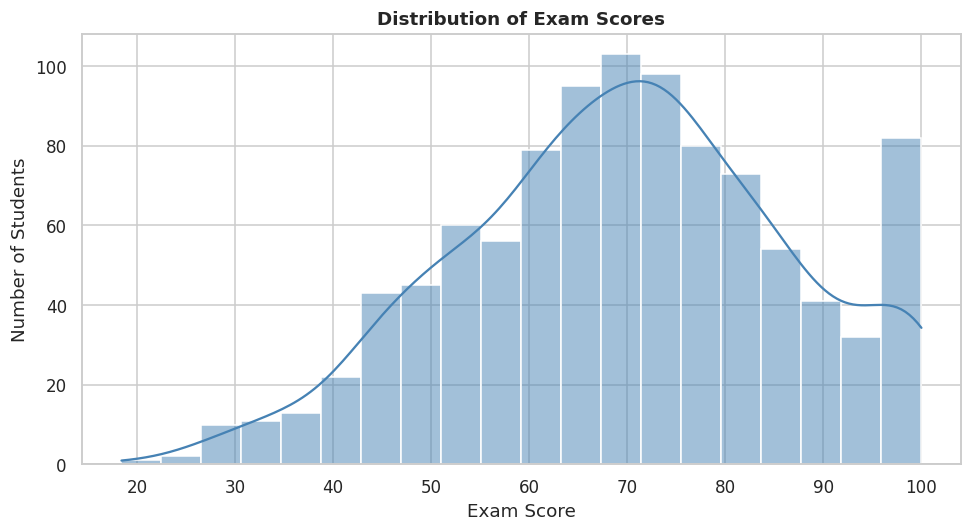

In [15]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="exam_score", bins=20, kde=True, color="steelblue")
plt.title("Distribution of Exam Scores", fontweight="bold")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

**Interpretation:** The histogram shows how exam scores are distributed across the students. The shape and spread provide a baseline understanding of student performance and help identify whether scores are concentrated, dispersed, or affected by extreme observations.

## 15. EDA — Distributions of Key Numerical Features

The selected predictors are visualized together to compare their distributions and identify skewness, concentration, and unusual values.

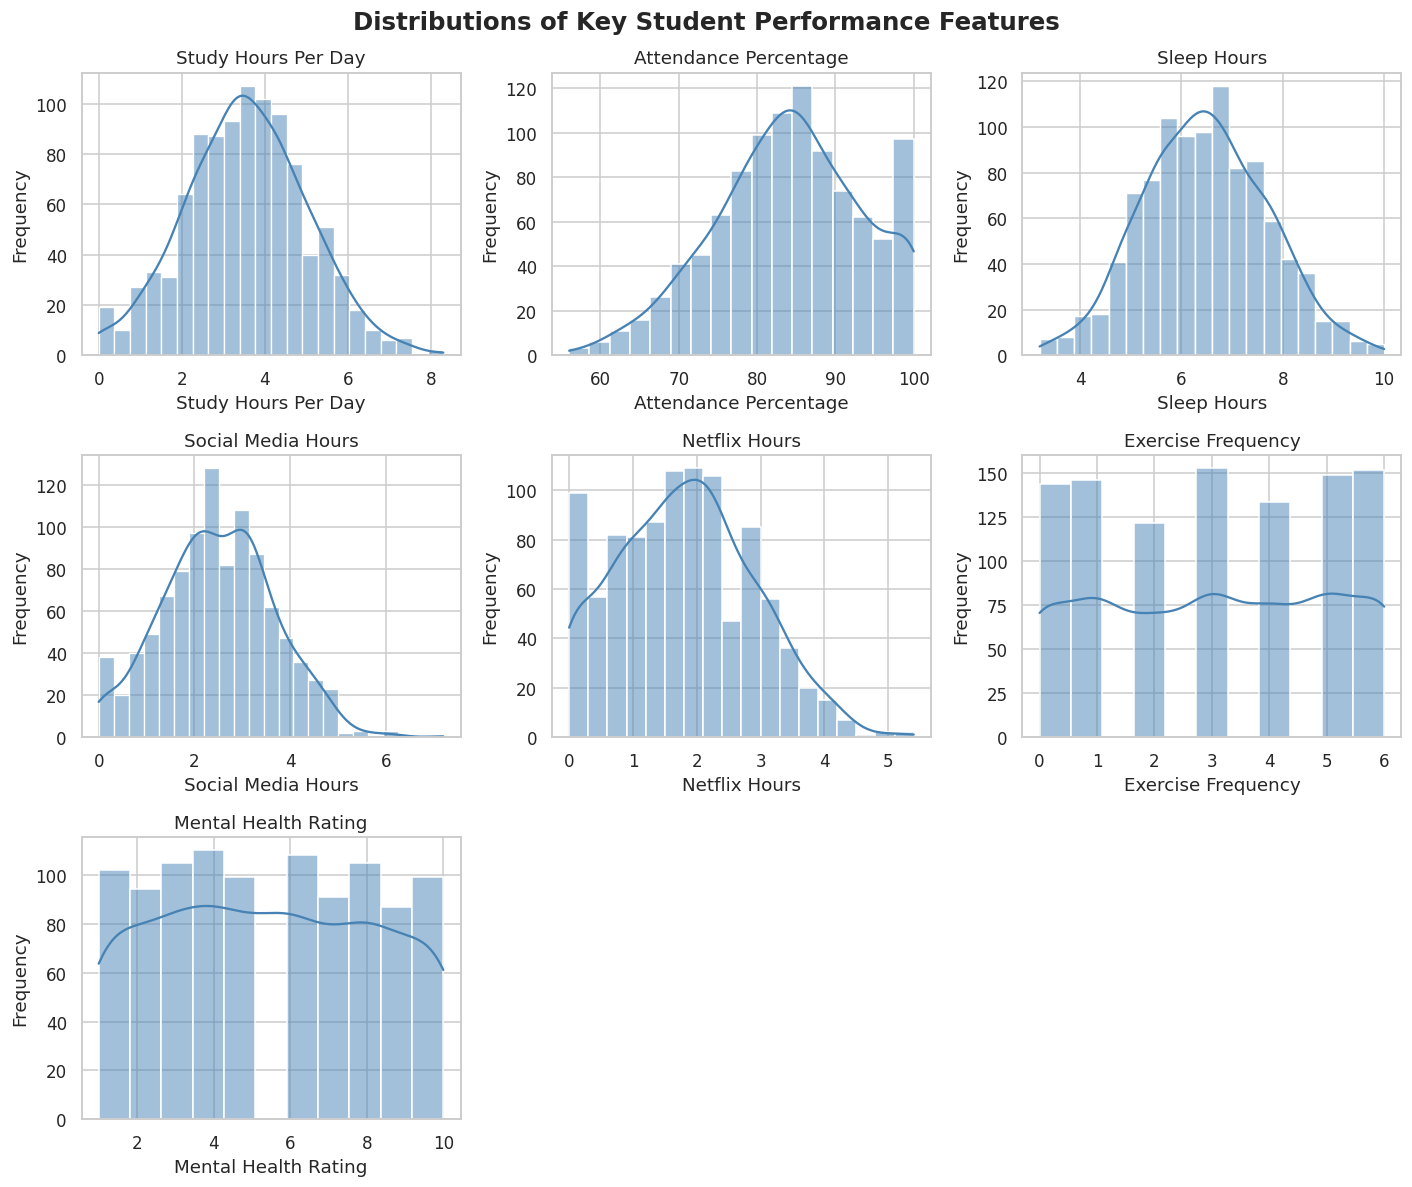

In [16]:
key_numeric = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours",
    "netflix_hours",
    "exercise_frequency",
    "mental_health_rating"
]

fig, axes = plt.subplots(3, 3, figsize=(13, 11))
axes = axes.flatten()

for ax, col in zip(axes, key_numeric):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Frequency")

for ax in axes[len(key_numeric):]:
    ax.remove()

plt.suptitle("Distributions of Key Student Performance Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** These distributions show the typical ranges and variability of the major student-behaviour and wellbeing variables. They also help identify whether any feature has strong skewness or unusual concentration that should be considered during preprocessing and interpretation.

## 16. EDA — Boxplots for Key Numerical Variables

Boxplots provide a compact view of the median, interquartile range, and potential outliers. Potential outliers are retained unless they are demonstrably invalid because extreme but genuine student behaviour can contain useful information.

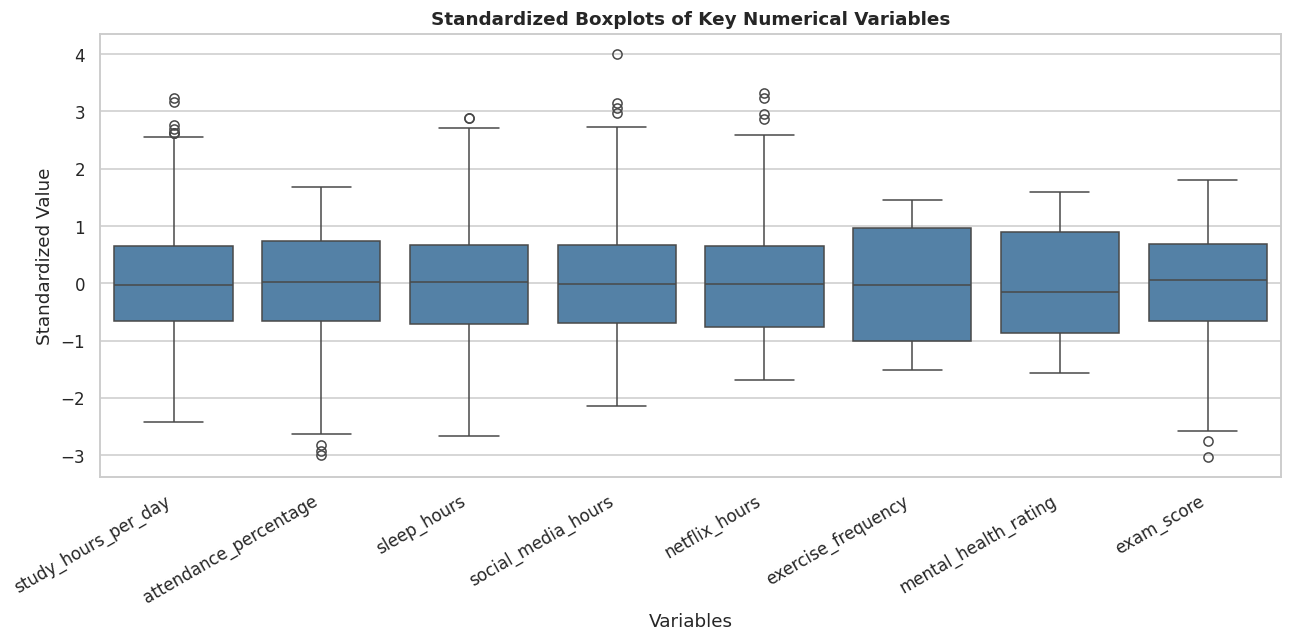

In [17]:
plot_cols = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours",
    "netflix_hours",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score"
]

scaled_for_plot = df[plot_cols].copy()
scaled_for_plot = (scaled_for_plot - scaled_for_plot.mean()) / scaled_for_plot.std()

plt.figure(figsize=(12, 6))
sns.boxplot(data=scaled_for_plot, color="steelblue")
plt.title("Standardized Boxplots of Key Numerical Variables", fontweight="bold")
plt.xlabel("Variables")
plt.ylabel("Standardized Value")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Interpretation:** The standardized boxplots make the relative spread of the variables easier to compare. Points beyond the whiskers are potential statistical outliers, but the notebook does not automatically delete them because they may represent valid student observations.

## 17. EDA — Correlation Matrix

Pearson correlations are calculated for numerical variables to identify linear relationships. Correlation measures association and does not by itself establish causation.

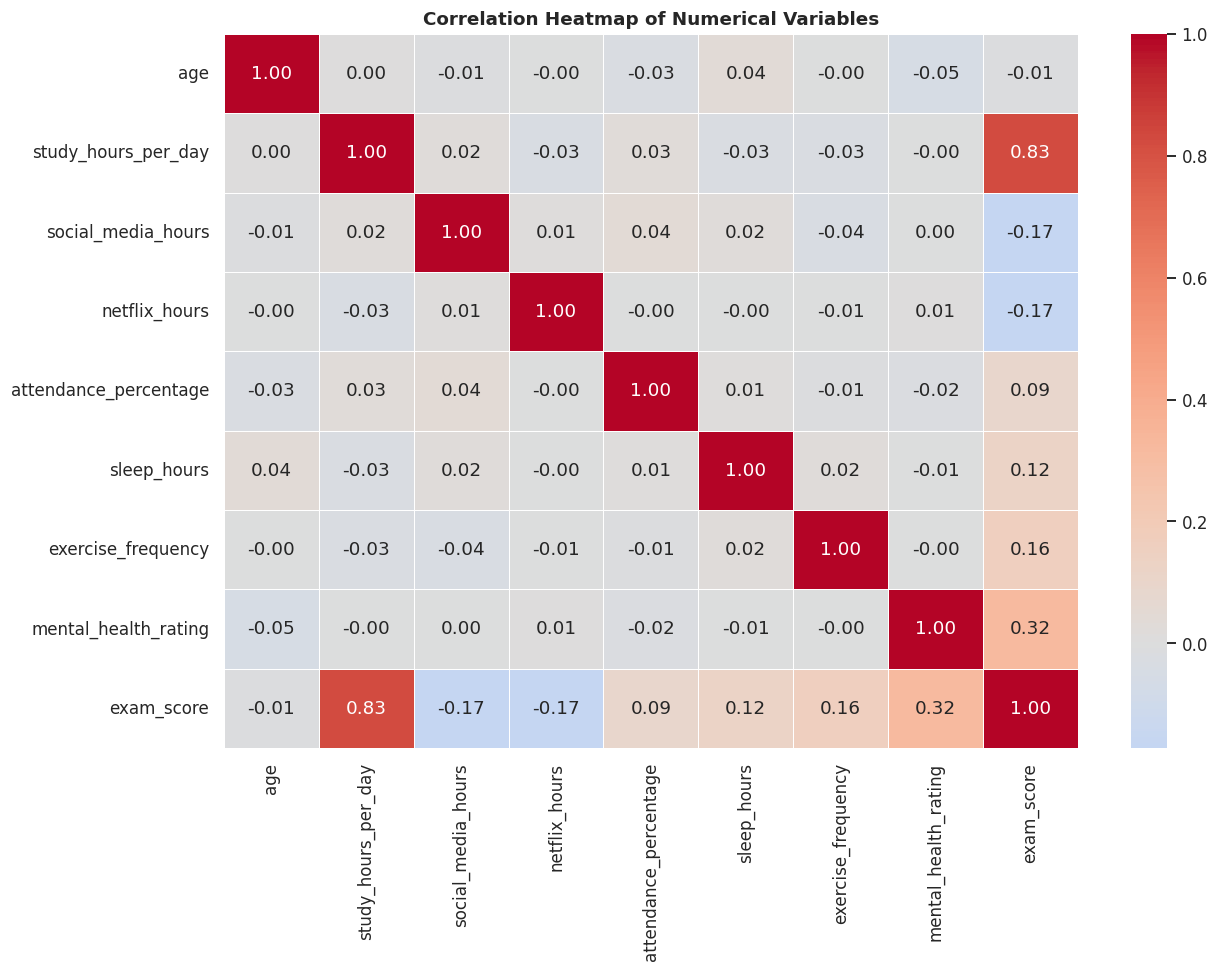

In [18]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation Heatmap of Numerical Variables", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap highlights which numerical variables move together most strongly. In particular, the correlations involving `exam_score` help identify candidate predictors for the regression and classification stages.

## 18. EDA — Numerical Relationships with Exam Score

This analysis ranks numerical variables by their Pearson correlation with `exam_score`. It directly addresses which measurable student factors appear most related to exam performance.

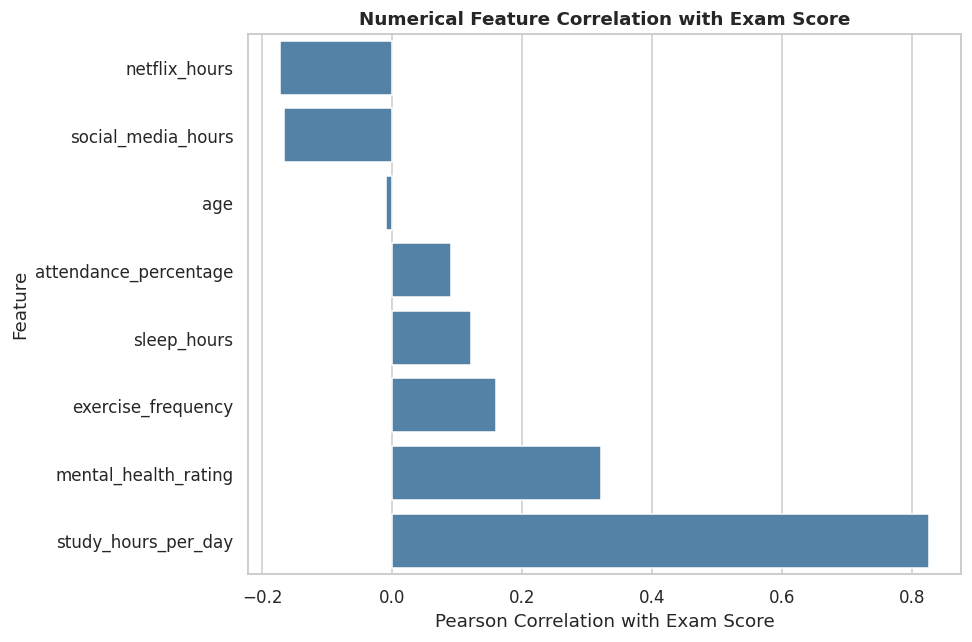

Correlation with exam_score:


,Correlation
netflix_hours,-0.172
social_media_hours,-0.167
age,-0.009
attendance_percentage,0.090
sleep_hours,0.122
exercise_frequency,0.160
mental_health_rating,0.322
study_hours_per_day,0.825


In [19]:
exam_corr = df[numerical_cols].corr()["exam_score"].drop("exam_score").sort_values()

plt.figure(figsize=(9, 6))
sns.barplot(x=exam_corr.values, y=exam_corr.index, orient="h", color="steelblue")
plt.title("Numerical Feature Correlation with Exam Score", fontweight="bold")
plt.xlabel("Pearson Correlation with Exam Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Correlation with exam_score:")
display(exam_corr.to_frame("Correlation").round(3))

**Interpretation:** Features with larger positive correlations tend to be associated with higher exam scores, while negative correlations indicate that higher values tend to coincide with lower scores. These are associations rather than causal effects and are used to guide feature selection and discussion.

## 19. EDA — Study Hours vs Exam Score

Study time is one of the explicitly suggested predictors in the assignment. A scatter plot is used to examine the relationship between daily study hours and exam performance.

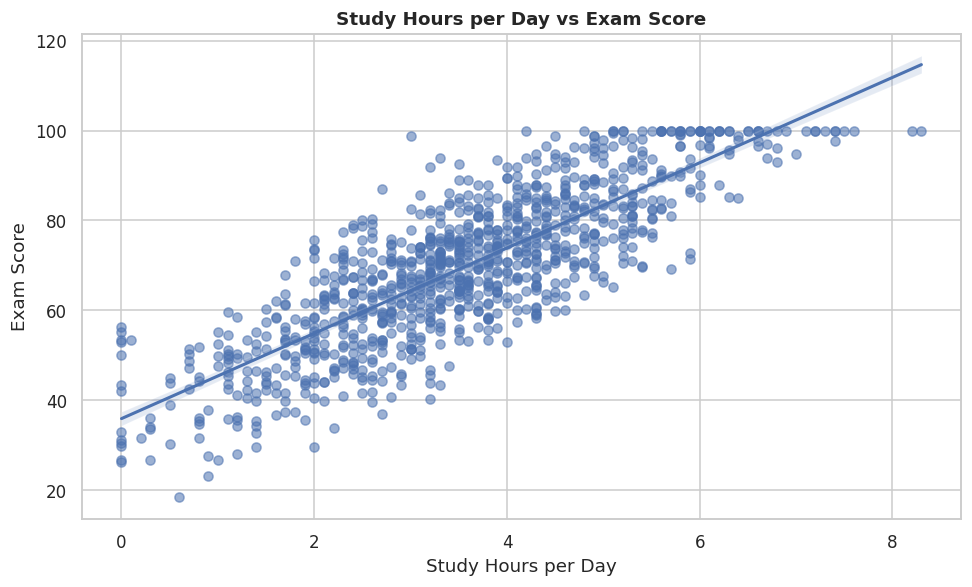

Pearson correlation: 0.825


In [20]:
plt.figure(figsize=(9, 5.5))
sns.regplot(data=df, x="study_hours_per_day", y="exam_score",
            scatter_kws={"alpha": 0.55}, line_kws={"linewidth": 2})
plt.title("Study Hours per Day vs Exam Score", fontweight="bold")
plt.xlabel("Study Hours per Day")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

print(f"Pearson correlation: {df['study_hours_per_day'].corr(df['exam_score']):.3f}")

**Interpretation:** The scatter plot and fitted trend line show the direction and strength of the association between study time and exam score. A positive slope would indicate that students who study more tend to have higher scores in the observed dataset.

## 20. EDA — Attendance vs Exam Score

Attendance percentage is another important candidate predictor. This scatter plot examines whether students with higher attendance tend to achieve higher exam scores.

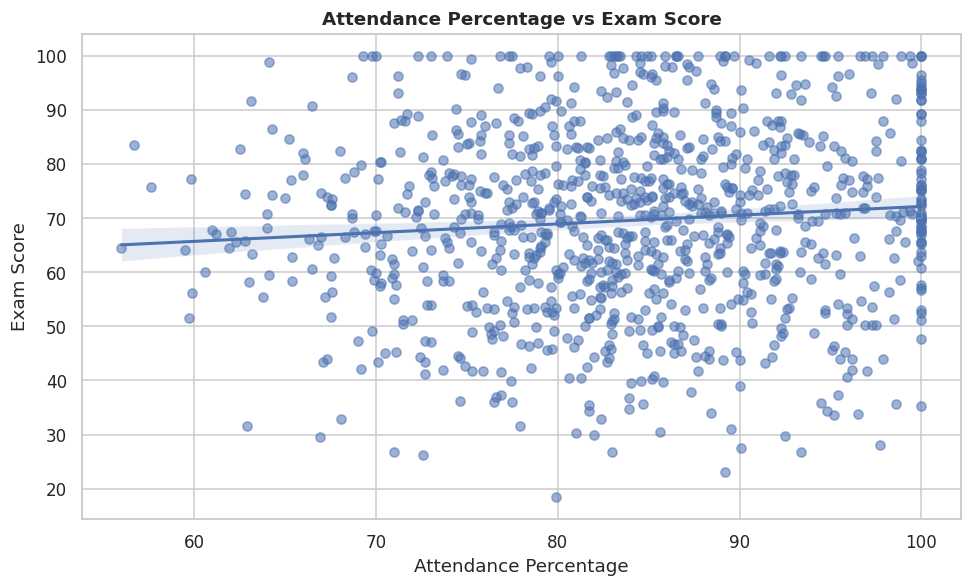

Pearson correlation: 0.090


In [21]:
plt.figure(figsize=(9, 5.5))
sns.regplot(data=df, x="attendance_percentage", y="exam_score",
            scatter_kws={"alpha": 0.55}, line_kws={"linewidth": 2})
plt.title("Attendance Percentage vs Exam Score", fontweight="bold")
plt.xlabel("Attendance Percentage")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

print(f"Pearson correlation: {df['attendance_percentage'].corr(df['exam_score']):.3f}")

**Interpretation:** The fitted trend indicates whether exam scores generally increase or decrease as attendance changes. The correlation printed below the chart quantifies the strength of the linear association.

## 21. EDA — Categorical Factors and Exam Score

Categorical variables can also be associated with exam performance. Boxplots compare score distributions across selected categories without assuming that the category itself causes the difference.

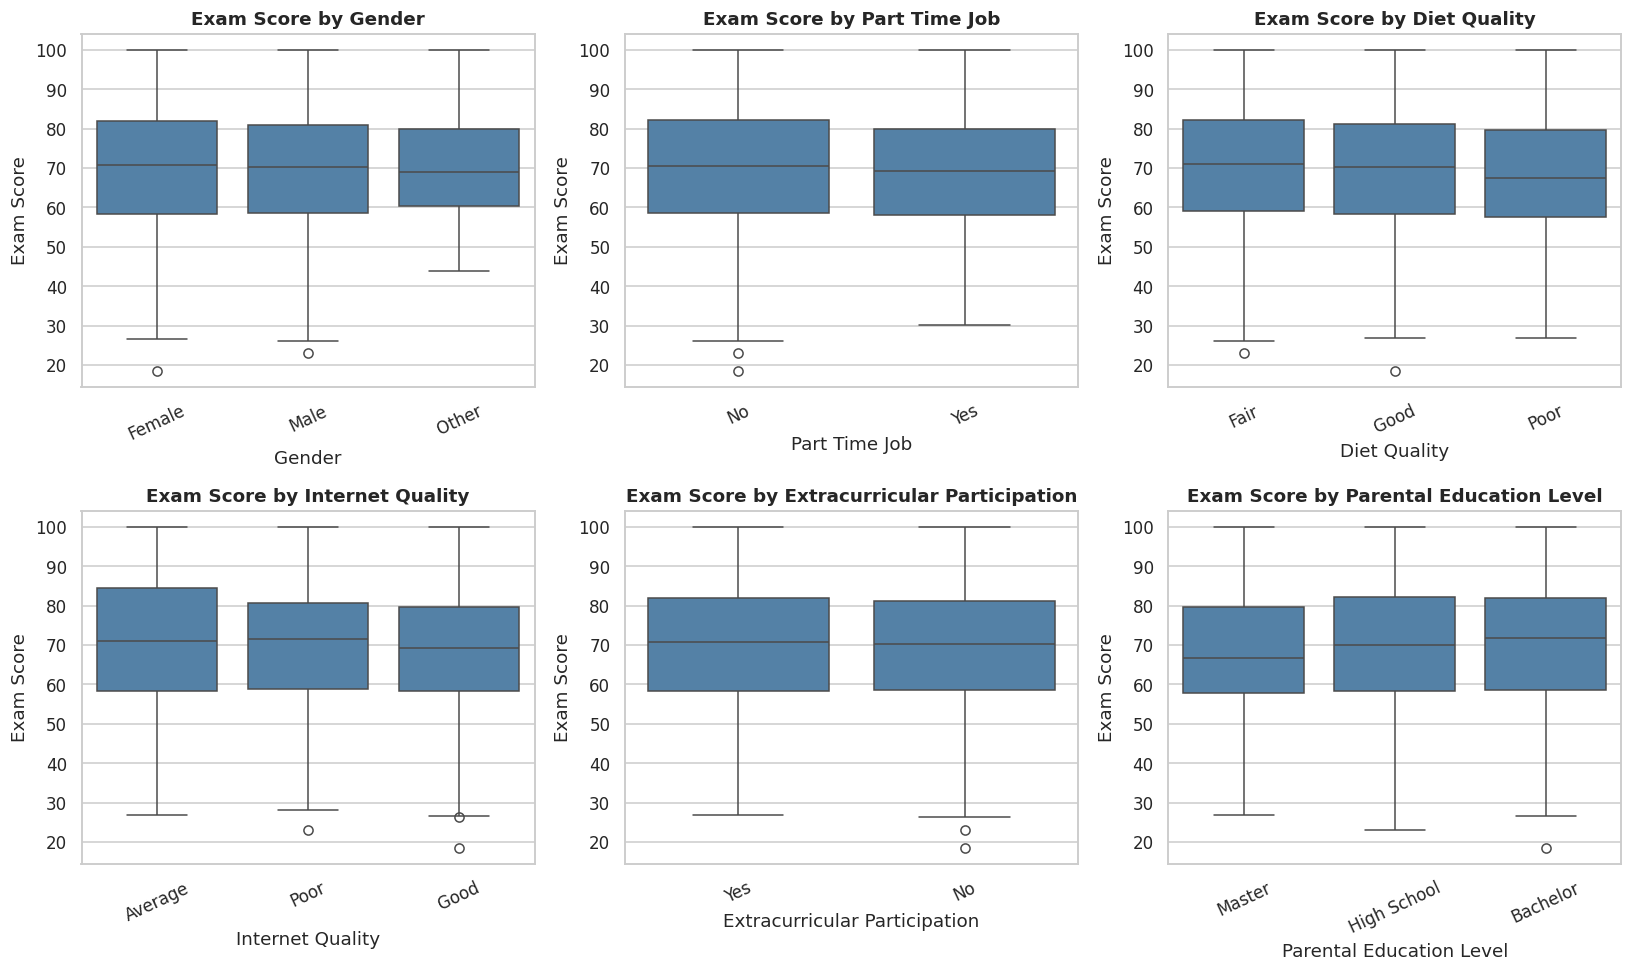

In [22]:
categorical_for_score = [
    "gender",
    "part_time_job",
    "diet_quality",
    "internet_quality",
    "extracurricular_participation",
    "parental_education_level"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, categorical_for_score):
    sns.boxplot(data=df, x=col, y="exam_score", ax=ax, color="steelblue")
    ax.set_title(f"Exam Score by {col.replace('_', ' ').title()}", fontweight="bold")
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Exam Score")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

**Interpretation:** These boxplots compare the centre and spread of exam scores across categorical groups. Noticeable differences between groups can identify potentially useful categorical predictors for the machine-learning models.

## 22. Data Preprocessing — Define Features and Targets

For regression, `exam_score` is the continuous target.

For classification, `exam_score` is converted into a binary target using the assignment's threshold:

**Pass = exam_score ≥ 50**

**Fail = exam_score < 50**

`student_id` is excluded because it is an identifier rather than a meaningful predictive feature. The original `exam_score` is also excluded from the feature matrix to prevent target leakage.

In [23]:
model_df = df.copy()

if duplicate_count > 0:
    model_df = model_df.drop_duplicates().copy()

model_df["pass_fail"] = np.where(model_df["exam_score"] >= 50, "Pass", "Fail")

feature_cols = [c for c in model_df.columns if c not in ["student_id", "exam_score", "pass_fail"]]

X = model_df[feature_cols].copy()
y_reg = model_df["exam_score"].copy()
y_clf = model_df["pass_fail"].copy()

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

print("Features used for both models:")
print(feature_cols)
print("\nRegression target: exam_score")
print("Classification target: pass_fail")
print("\nCategorical features:", categorical_features)
print("Numerical features:", numeric_features)

Features used for both models:
['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']

Regression target: exam_score
Classification target: pass_fail

Categorical features: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']
Numerical features: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']


## 23. Preprocessing Pipeline

The preprocessing is fitted only on the training data through scikit-learn pipelines, preventing information leakage from the test set.

- Numerical variables: median imputation + standardization
- Categorical variables: most-frequent imputation + one-hot encoding

This approach uses the actual dataset structure and handles the missing `parental_education_level` values appropriately.

In [24]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", **(
    {"sparse_output": False}
    if "sparse_output" in __import__("inspect").signature(OneHotEncoder).parameters
    else {"sparse": False}
)))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 24. Train/Test Split for Regression

The data is split into training and testing sets using an 80/20 split. A fixed `random_state` makes the results reproducible.

In [25]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.20, random_state=42
)

print("Regression training rows:", len(X_train_reg))
print("Regression testing rows:", len(X_test_reg))

Regression training rows: 800
Regression testing rows: 200


## 25. Linear Regression Model

Linear Regression predicts a continuous target by estimating a linear relationship between the prepared features and `exam_score`.

Conceptually:

**Predicted score = intercept + weighted contribution of the prepared features**

In [26]:
regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

regression_model.fit(X_train_reg, y_train_reg)

y_train_pred = regression_model.predict(X_train_reg)
y_test_pred = regression_model.predict(X_test_reg)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


## 26. Regression Predictions

The first few actual and predicted scores are displayed to show how the trained model performs on unseen test observations.

In [27]:
prediction_comparison = pd.DataFrame({
    "Actual_Exam_Score": y_test_reg.reset_index(drop=True),
    "Predicted_Exam_Score": np.round(y_test_pred, 2)
})

display(prediction_comparison.head(10))

,Actual_Exam_Score,Predicted_Exam_Score
0,64.2,66.20
1,72.7,75.12
2,79.0,78.06
3,79.5,73.33
4,58.2,61.02
5,53.4,54.06
6,70.8,75.57
7,62.5,55.04
8,36.8,40.67
9,67.6,72.42


## 27. Regression Evaluation

The regression model is evaluated using the standard metrics covered in introductory machine learning:

- **MAE:** average absolute prediction error
- **MSE:** average squared prediction error
- **RMSE:** square root of MSE, expressed in score units
- **R²:** proportion of variance explained by the model

In [28]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

reg_train_metrics = regression_metrics(y_train_reg, y_train_pred)
reg_test_metrics = regression_metrics(y_test_reg, y_test_pred)

regression_results = pd.DataFrame(
    [reg_train_metrics, reg_test_metrics],
    index=["Training", "Testing"]
)

display(regression_results.round(3))

,MAE,MSE,RMSE,R2
Training,4.214,28.566,5.345,0.902
Testing,4.192,26.533,5.151,0.897


**Interpretation:** Lower MAE, MSE, and RMSE indicate smaller prediction errors, while a higher R² indicates that the model explains more variation in exam scores. The training and testing values should be considered together when judging generalization.

## 28. Regression — Actual vs Predicted Scores

A scatter plot of actual versus predicted test scores visually evaluates how closely predictions follow the ideal 45-degree relationship.

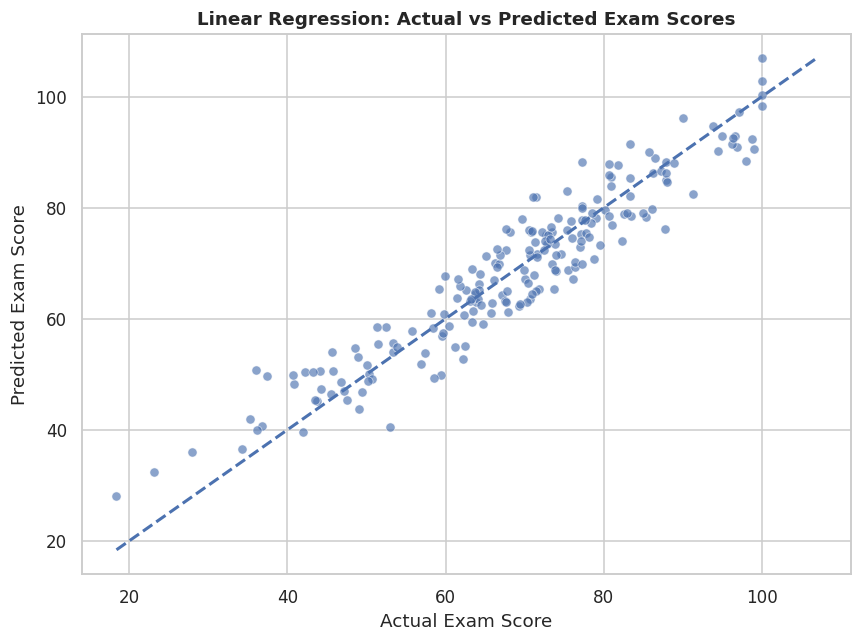

In [29]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_test_pred, alpha=0.65)

min_score = min(y_test_reg.min(), y_test_pred.min())
max_score = max(y_test_reg.max(), y_test_pred.max())
plt.plot([min_score, max_score], [min_score, max_score], linestyle="--", linewidth=2)

plt.title("Linear Regression: Actual vs Predicted Exam Scores", fontweight="bold")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.tight_layout()
plt.show()

**Interpretation:** Points closer to the diagonal reference line represent more accurate predictions. Systematic deviations from the line indicate prediction errors and can reveal where the linear model struggles.

## 29. Regression — Residual Analysis

Residuals are calculated as actual score minus predicted score. Their distribution helps assess whether errors are centred around zero and whether unusually large errors are present.

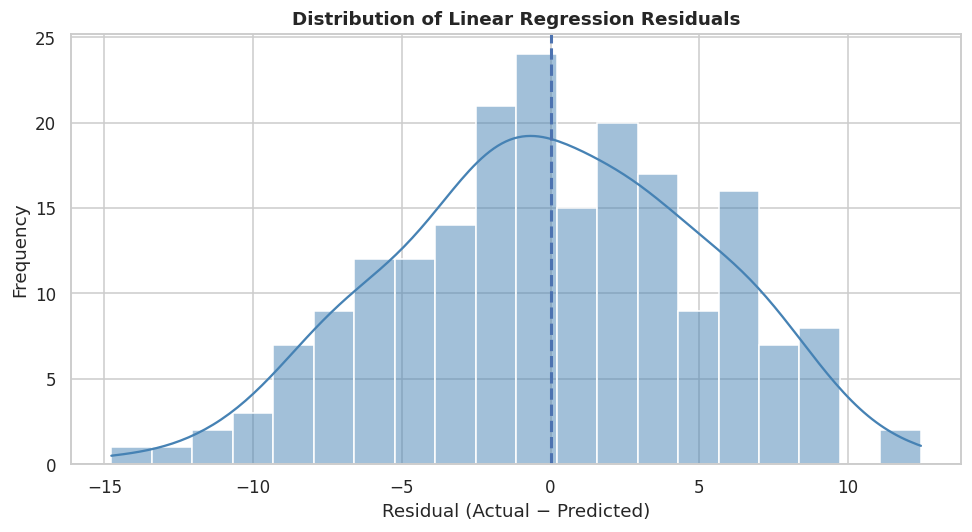

In [30]:
residuals = y_test_reg - y_test_pred

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=20, kde=True, color="steelblue")
plt.axvline(0, linestyle="--", linewidth=2)
plt.title("Distribution of Linear Regression Residuals", fontweight="bold")
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** A residual distribution centred reasonably around zero suggests that the model does not consistently overpredict or underpredict. A wide distribution indicates larger prediction errors.

## 30. Classification Target — Pass/Fail at 50 Marks

The classification problem uses the exact assignment rule:

**Pass = exam_score ≥ 50**

**Fail = exam_score < 50**

The resulting class distribution is checked before training.

,Student_Count
pass_fail,
Fail,131
Pass,869


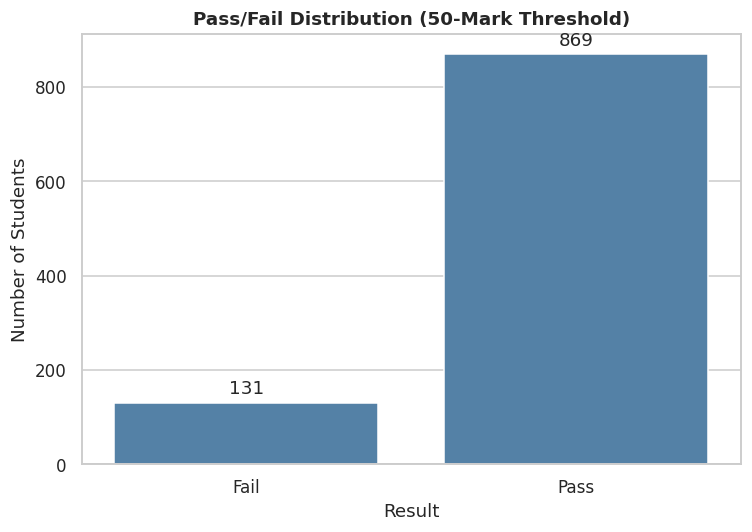

In [31]:
class_counts = y_clf.value_counts().reindex(["Fail", "Pass"]).fillna(0).astype(int)

display(class_counts.to_frame("Student_Count"))

plt.figure(figsize=(7, 5))
ax = sns.countplot(x=y_clf, order=["Fail", "Pass"], color="steelblue")
plt.title("Pass/Fail Distribution (50-Mark Threshold)", fontweight="bold")
plt.xlabel("Result")
plt.ylabel("Number of Students")
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

**Interpretation:** The count plot shows how many students fall below and at/above the 50-mark passing threshold. This class balance is important when interpreting classification metrics.

## 31. Train/Test Split for Classification

The classification model uses the same prepared feature set as the regression workflow, with `pass_fail` as the target. Stratification preserves the approximate Pass/Fail proportion in both subsets.

In [32]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

print("Classification training rows:", len(X_train_clf))
print("Classification testing rows:", len(X_test_clf))

Classification training rows: 800
Classification testing rows: 200


## 32. Logistic Regression Classification Model

Logistic Regression is used as an appropriate baseline binary classifier for the Pass/Fail target. The preprocessing pipeline is fitted using the training data only.

In [33]:
classification_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

classification_model.fit(X_train_clf, y_train_clf)

y_train_clf_pred = classification_model.predict(X_train_clf)
y_test_clf_pred = classification_model.predict(X_test_clf)

print("Logistic Regression classifier trained successfully.")

Logistic Regression classifier trained successfully.


## 33. Classification Evaluation

The required classification metrics are:

- **Accuracy:** proportion of all predictions that are correct
- **Precision:** proportion of predicted Pass cases that are actually Pass
- **Recall:** proportion of actual Pass cases correctly identified
- **F1-score:** harmonic mean of precision and recall

The metrics are calculated for the testing set and also compared with training performance.

In [34]:
classification_results = pd.DataFrame({
    "Training": [
        accuracy_score(y_train_clf, y_train_clf_pred),
        precision_score(y_train_clf, y_train_clf_pred, pos_label="Pass", zero_division=0),
        recall_score(y_train_clf, y_train_clf_pred, pos_label="Pass", zero_division=0),
        f1_score(y_train_clf, y_train_clf_pred, pos_label="Pass", zero_division=0)
    ],
    "Testing": [
        accuracy_score(y_test_clf, y_test_clf_pred),
        precision_score(y_test_clf, y_test_clf_pred, pos_label="Pass", zero_division=0),
        recall_score(y_test_clf, y_test_clf_pred, pos_label="Pass", zero_division=0),
        f1_score(y_test_clf, y_test_clf_pred, pos_label="Pass", zero_division=0)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-Score"])

display(classification_results.round(3))

,Training,Testing
Accuracy,0.958,0.955
Precision,0.970,0.971
Recall,0.981,0.977
F1-Score,0.976,0.974


**Interpretation:** Higher values indicate better classification performance for all four metrics. Testing performance is more important for estimating how the classifier is likely to perform on unseen students.

## 34. Confusion Matrix

The confusion matrix shows the four possible classification outcomes. Rows represent actual classes and columns represent predicted classes.

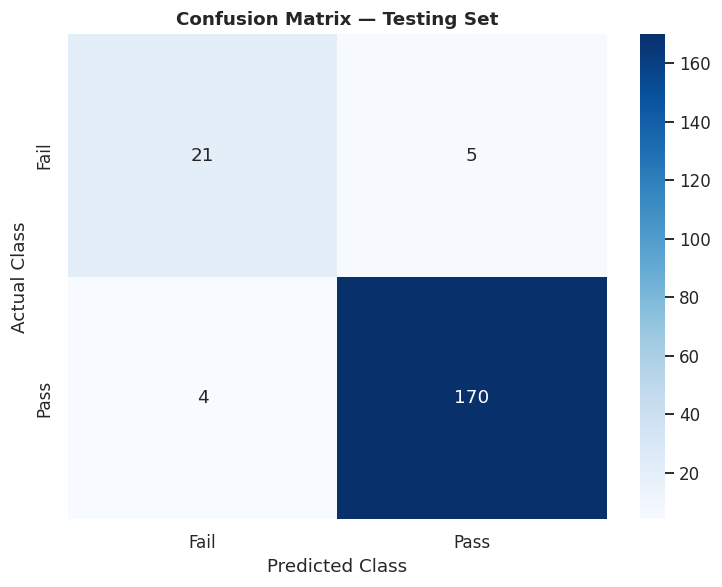

Classification report:
              precision    recall  f1-score   support

        Fail       0.84      0.81      0.82        26
        Pass       0.97      0.98      0.97       174

    accuracy                           0.95       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.95      0.95      0.95       200



In [35]:
cm = confusion_matrix(y_test_clf, y_test_clf_pred, labels=["Fail", "Pass"])

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)
plt.title("Confusion Matrix — Testing Set", fontweight="bold")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print("Classification report:")
print(classification_report(
    y_test_clf, y_test_clf_pred,
    labels=["Fail", "Pass"],
    zero_division=0
))

**Interpretation:** The diagonal cells are correct predictions, while off-diagonal cells are classification errors. In an academic-support context, false negatives (actual Pass predicted as Fail) and false positives (actual Fail predicted as Pass) can have different practical implications and should therefore be considered alongside the summary metrics.

## 35. Training vs Testing Performance — Overfitting / Underfitting

A model can overfit when training performance is substantially better than testing performance. It can underfit when both training and testing performance are relatively weak.

The comparison below uses the observed metrics rather than assuming overfitting or underfitting in advance.

In [36]:
reg_gap_r2 = reg_train_metrics["R2"] - reg_test_metrics["R2"]
reg_gap_rmse = reg_test_metrics["RMSE"] - reg_train_metrics["RMSE"]

clf_gap_f1 = (
    classification_results.loc["F1-Score", "Training"]
    - classification_results.loc["F1-Score", "Testing"]
)

print(f"Regression R² — Training: {reg_train_metrics['R2']:.3f}")
print(f"Regression R² — Testing:  {reg_test_metrics['R2']:.3f}")
print(f"Regression RMSE — Training: {reg_train_metrics['RMSE']:.3f}")
print(f"Regression RMSE — Testing:  {reg_test_metrics['RMSE']:.3f}")
print(f"Regression R² gap: {reg_gap_r2:.3f}")
print()
print(f"Classification F1 — Training: {classification_results.loc['F1-Score', 'Training']:.3f}")
print(f"Classification F1 — Testing:  {classification_results.loc['F1-Score', 'Testing']:.3f}")
print(f"Classification F1 gap: {clf_gap_f1:.3f}")

if reg_gap_r2 > 0.15 or clf_gap_f1 > 0.15:
    print("\nAssessment: There are signs of possible overfitting because training performance is noticeably stronger than testing performance.")
elif reg_train_metrics["R2"] < 0.30 and reg_test_metrics["R2"] < 0.30:
    print("\nAssessment: The regression model shows relatively weak explanatory power on both sets, suggesting possible underfitting or limited predictive information in the selected features.")
else:
    print("\nAssessment: The training and testing results do not show a large performance gap by these practical thresholds, so there is no strong evidence of severe overfitting.")

Regression R² — Training: 0.902
Regression R² — Testing:  0.897
Regression RMSE — Training: 5.345
Regression RMSE — Testing:  5.151
Regression R² gap: 0.006

Classification F1 — Training: 0.976
Classification F1 — Testing:  0.974
Classification F1 gap: 0.001

Assessment: The training and testing results do not show a large performance gap by these practical thresholds, so there is no strong evidence of severe overfitting.


**Interpretation:** The conclusion above is based on the actual train/test metric gap. A small gap with reasonable testing performance suggests better generalization, whereas a large gap indicates that the model may be learning patterns specific to the training sample.

## 36. Most Important Regression Features

The fitted Linear Regression model provides coefficients for the prepared features. Because numerical variables were standardized and categorical variables were one-hot encoded, coefficient magnitudes can be compared as an indication of the model's linear contribution.

These coefficients describe model association, not causation.

,Feature,Coefficient,Absolute_Coefficient
1,num__study_hours_per_day,14.145,14.145
7,num__mental_health_rating,5.565,5.565
2,num__social_media_hours,-3.130,3.130
6,num__exercise_frequency,2.657,2.657
3,num__netflix_hours,-2.532,2.532
5,num__sleep_hours,2.422,2.422
4,num__attendance_percentage,1.350,1.350
13,cat__diet_quality_Fair,0.503,0.503
10,cat__gender_Other,0.492,0.492
14,cat__diet_quality_Good,-0.455,0.455


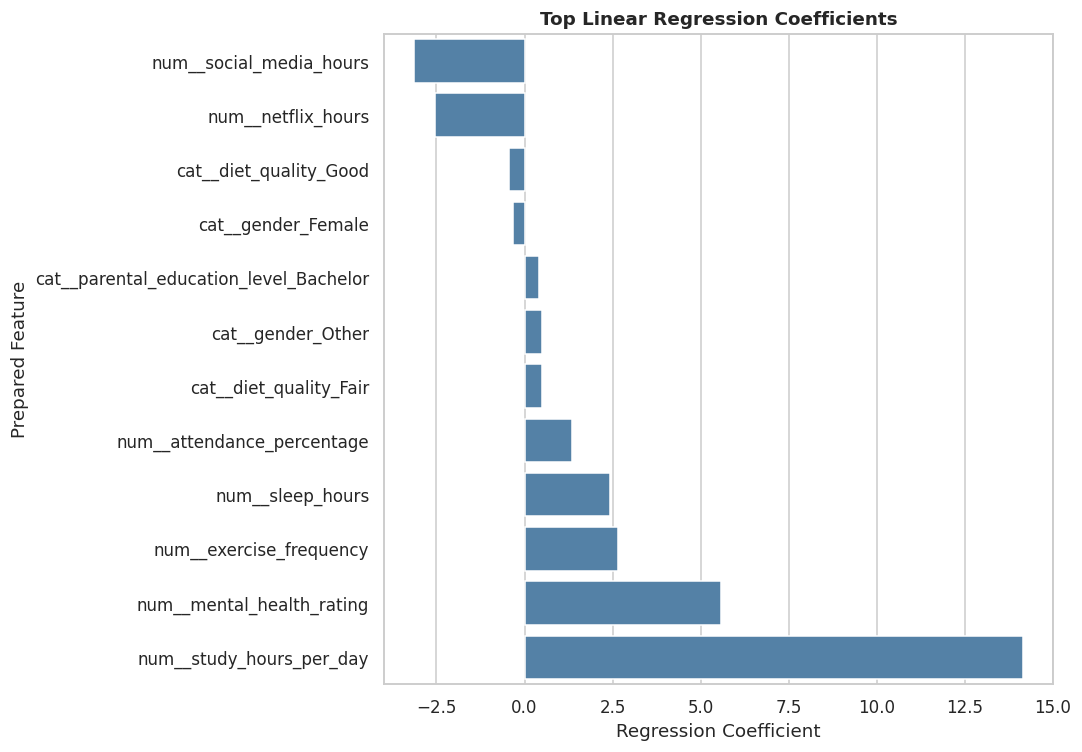

In [37]:
fitted_preprocessor = regression_model.named_steps["preprocessor"]
fitted_lr = regression_model.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = fitted_lr.coef_

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values("Absolute_Coefficient", ascending=False)

display(coef_table.head(15).round(3))

plt.figure(figsize=(10, 7))
top_coef = coef_table.head(12).sort_values("Coefficient")
sns.barplot(data=top_coef, x="Coefficient", y="Feature", color="steelblue")
plt.title("Top Linear Regression Coefficients", fontweight="bold")
plt.xlabel("Regression Coefficient")
plt.ylabel("Prepared Feature")
plt.tight_layout()
plt.show()

**Interpretation:** Features with larger absolute coefficients have stronger influence on the Linear Regression prediction within this standardized model. Positive coefficients are associated with higher predicted exam scores, while negative coefficients are associated with lower predicted scores, holding the other model features constant.

## 37. Executive Findings from EDA and Models

The following code collects the strongest numerical relationships and the final model metrics so the conclusions remain directly tied to the computed results rather than manually invented values.

In [38]:
strongest_positive_feature = exam_corr.idxmax()
strongest_negative_feature = exam_corr.idxmin()

print(f"Strongest positive numerical correlation with exam_score: {strongest_positive_feature} ({exam_corr.max():.3f})")
print(f"Strongest negative numerical correlation with exam_score: {strongest_negative_feature} ({exam_corr.min():.3f})")
print(f"Testing regression R²: {reg_test_metrics['R2']:.3f}")
print(f"Testing regression RMSE: {reg_test_metrics['RMSE']:.3f}")
print(f"Testing classification accuracy: {classification_results.loc['Accuracy', 'Testing']:.3f}")
print(f"Testing classification F1-score: {classification_results.loc['F1-Score', 'Testing']:.3f}")

Strongest positive numerical correlation with exam_score: study_hours_per_day (0.825)
Strongest negative numerical correlation with exam_score: netflix_hours (-0.172)
Testing regression R²: 0.897
Testing regression RMSE: 5.151
Testing classification accuracy: 0.955
Testing classification F1-score: 0.974


## 38. Five Meaningful Student-Performance Insights

The five observations below are generated from the actual analysis results. They focus on relationships and model evidence rather than claiming causation.

1. **Strongest numerical relationship:** the numerical feature with the strongest positive correlation with `exam_score` is identified directly from the dataset.
2. **Negative relationship:** the feature with the strongest negative correlation with `exam_score` provides a contrasting performance signal.
3. **Regression usefulness:** the testing R² and RMSE indicate how accurately the selected student-behaviour and wellbeing variables predict exam scores.
4. **Pass/Fail prediction:** testing accuracy, precision, recall, and F1-score show how effectively the classifier separates students around the 50-mark threshold.
5. **Generalization:** the difference between training and testing performance indicates whether the models generalize reasonably or show signs of overfitting/underfitting.

In [39]:
print("1. Strongest positive numerical relationship:")
print(f"   {strongest_positive_feature} has the strongest positive correlation with exam_score ({exam_corr.max():.3f}).")

print("\n2. Strongest negative numerical relationship:")
print(f"   {strongest_negative_feature} has the strongest negative correlation with exam_score ({exam_corr.min():.3f}).")

print("\n3. Regression performance:")
print(f"   The Linear Regression model achieved a testing R² of {reg_test_metrics['R2']:.3f} "
      f"with an RMSE of {reg_test_metrics['RMSE']:.2f} marks.")

print("\n4. Classification performance:")
print(f"   The Pass/Fail classifier achieved testing accuracy of "
      f"{classification_results.loc['Accuracy', 'Testing']:.3f} and F1-score of "
      f"{classification_results.loc['F1-Score', 'Testing']:.3f}.")

print("\n5. Generalization:")
if reg_gap_r2 > 0.15 or clf_gap_f1 > 0.15:
    print("   Training performance is noticeably higher than testing performance, indicating possible overfitting.")
elif reg_train_metrics["R2"] < 0.30 and reg_test_metrics["R2"] < 0.30:
    print("   Both regression R² values are relatively low, suggesting limited predictive power and possible underfitting.")
else:
    print("   Training and testing performance are reasonably close, with no strong evidence of severe overfitting.")

1. Strongest positive numerical relationship:
   study_hours_per_day has the strongest positive correlation with exam_score (0.825).

2. Strongest negative numerical relationship:
   netflix_hours has the strongest negative correlation with exam_score (-0.172).

3. Regression performance:
   The Linear Regression model achieved a testing R² of 0.897 with an RMSE of 5.15 marks.

4. Classification performance:
   The Pass/Fail classifier achieved testing accuracy of 0.955 and F1-score of 0.974.

5. Generalization:
   Training and testing performance are reasonably close, with no strong evidence of severe overfitting.


## 39. Final Summary

This notebook completed the requested end-to-end machine-learning workflow on the exact Student Performance dataset.

The analysis began with dataset inspection and EDA, including distributions, missing values, duplicate checks, categorical consistency, numerical validity, potential outliers, correlations, and relationships with `exam_score`.

The data was then prepared using a reproducible preprocessing pipeline. `exam_score` was modeled as a continuous regression target using Linear Regression. A second classification task converted the score into **Pass/Fail using 50 marks** and used Logistic Regression with the same prepared feature set.

Model predictions were evaluated using regression metrics and the required classification metrics, including a confusion matrix. Training and testing performance were compared to assess generalization and possible overfitting or underfitting.

**Overall conclusion:** The strongest predictors and model performance should be interpreted as patterns observed in this dataset, not as proof that one student behaviour directly causes a particular exam result.

## 40. Analytical Notes and Limitations

- The notebook uses the **exact supplied CSV dataset** and does not fabricate observations or variables.
- Missing values are handled within the preprocessing pipeline rather than by leaking information from the test set.
- Potential IQR outliers are identified for EDA but are not blindly deleted because extreme student observations may be genuine.
- `student_id` is excluded because it is an identifier rather than a meaningful predictive feature.
- `exam_score` is excluded from the feature matrix to prevent target leakage.
- Correlation and model coefficients indicate statistical/model associations, not causation.
- A single train/test split provides a useful baseline evaluation, but cross-validation and hyperparameter tuning could provide a more robust future assessment.
- The classification threshold of **50 marks** follows the assignment exactly.